# Solución — Formalización de una instancia del TSP

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/UdeA-IoT//ESP-ACO/blob/main/ACO/metaheuristic-ACO/parte2/TSP/notebooks/tsp-exercise-solucion.ipynb)

**Proyecto:** ESP-ACO (UdeA) — notas complementarias de optimización combinatoria,
basadas en Dorigo & Stützle, *Ant Colony Optimization* (MIT Press, 2004), §2.1, §2.2.1,
§2.3.1 y capítulo 3 (ecuación 3.1).

**Enunciado de referencia:** [`../TSP-exercise.md`](../TSP-exercise.md) — este notebook
resuelve, paso a paso y con código ejecutable, los numerales (a) a (j) de ese documento.
Es autocontenido: no necesitas tener el enunciado abierto para seguirlo, aunque conviene
leerlo primero para tener el contexto completo del problema.

## Antes de empezar — tres cosas que probablemente ya sabes

Estas tres ideas son de ciencia básica y las vamos a dar por conocidas de aquí en
adelante, sin detenernos a re-explicarlas cada vez que aparezcan:

- **Factorial ($n!$):** el producto de todos los enteros positivos hasta $n$. Por ejemplo,
  $4! = 4 \times 3 \times 2 \times 1 = 24$.
- **Permutación:** un reordenamiento de *todos* los elementos de un conjunto, donde el
  orden importa. Por ejemplo, con $\{X, Y, Z\}$, $XYZ$ y $ZYX$ son permutaciones
  distintas del mismo conjunto.
- **Notación de conjuntos:** $A \subseteq B$ se lee "todo elemento de $A$ también está
  en $B$" (A es subconjunto de B, posiblemente igual a B). $A \subsetneq B$ es lo mismo
  pero exigiendo que sean distintos.

Lo que **sí** vamos a explicar "de coquito", en el momento exacto en que aparece por
primera vez, son los conceptos propios del formalismo de optimización combinatoria /
ACO — porque son los que el libro asume conocidos y casi nunca lo son de verdad.

In [1]:
import itertools
import math
import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch

plt.rcParams.update({"font.size": 11, "axes.spines.top": False, "axes.spines.right": False})


---
## a) Componentes $C$ y tamaño $n$

$C$ es, literalmente, el conjunto de "piezas" con las que se construye una solución.
En el TSP, cada pieza es una ciudad — no hay nada más elaborado detrás de este símbolo.

$$C = \{A, B, C, D\}, \qquad n = |C| = 4$$

In [2]:
C = ['A', 'B', 'C', 'D']
n = len(C)

print(f"C = {C}")
print(f"n = |C| = {n}")


C = ['A', 'B', 'C', 'D']
n = |C| = 4


---
## b) Conjunto $S$ y $|S|$

**Coquito — ¿por qué $n!$?** Para construir una permutación de $n$ ciudades, tienes $n$
opciones para elegir la primera ciudad, $n-1$ opciones para la segunda (ya usaste una),
$n-2$ para la tercera, y así sucesivamente hasta que solo queda 1 opción para la última.
Multiplicando todas esas opciones:

$$n \times (n-1) \times (n-2) \times \cdots \times 1 = n!$$

$S$ es el conjunto de **todas** las permutaciones de las 4 ciudades, interpretada cada una
como un tour cerrado (regresa al inicio). Como aquí construimos $S$ *directamente* como
permutaciones, cada elemento ya "trae incorporada" la propiedad de visitar cada ciudad
una vez — un detalle que retomamos con más cuidado en el numeral (d).

In [3]:
S = list(itertools.permutations(C))

print(f"|S| = {len(S)}  (esperado: 4! = {math.factorial(4)})")
print("\nPrimeros 5 elementos de S:")
for s in S[:5]:
    print(" ", s)
print("  ...")


|S| = 24  (esperado: 4! = 24)

Primeros 5 elementos de S:
  ('A', 'B', 'C', 'D')
  ('A', 'B', 'D', 'C')
  ('A', 'C', 'B', 'D')
  ('A', 'C', 'D', 'B')
  ('A', 'D', 'B', 'C')
  ...


---
## c) Reducción por rotación: permutaciones circulares

**Coquito — la analogía de la mesa redonda.** Imagina 4 amigos sentados en una mesa
redonda. Si los 4 se levantan y se corren un puesto en la misma dirección, ¿es una
disposición *distinta*? No — es exactamente el mismo arreglo relativo entre las personas,
solo que empezaste a "leer" la mesa desde otro punto. Un tour de TSP funciona igual: el
tour $A{\to}B{\to}C{\to}D{\to}A$ es *físicamente la misma ruta* que
$B{\to}C{\to}D{\to}A{\to}B$ — el vendedor recorre exactamente las mismas calles.

Esto significa que, de las $n!$ permutaciones de $S$, cada grupo de $n$ rotaciones
representa **la misma solución**. Por eso dividimos entre $n$:

$$\frac{n!}{n} = (n-1)!$$

Vamos a verlo con código, agrupando cada una de las 24 permutaciones por su forma
canónica (todas las rotaciones que empiezan en la ciudad $A$ terminan en el mismo grupo).

In [4]:
def clase_circular(tour):
    """Rota el tour para que siempre empiece en 'A' -- agrupa las rotaciones equivalentes."""
    idx = tour.index('A')
    return tour[idx:] + tour[:idx]

clases = {}
for s in S:
    key = clase_circular(s)
    clases.setdefault(key, []).append(s)

print(f"Numero de clases circulares: {len(clases)}  (esperado: (4-1)! = {math.factorial(3)})")
print()
for key, miembros in clases.items():
    tour_str = "->".join(key) + f"->{key[0]}"
    print(f"{tour_str:20s}  <-  {len(miembros)} rotaciones equivalentes: {miembros}")


Numero de clases circulares: 6  (esperado: (4-1)! = 6)

A->B->C->D->A         <-  4 rotaciones equivalentes: [('A', 'B', 'C', 'D'), ('B', 'C', 'D', 'A'), ('C', 'D', 'A', 'B'), ('D', 'A', 'B', 'C')]
A->B->D->C->A         <-  4 rotaciones equivalentes: [('A', 'B', 'D', 'C'), ('B', 'D', 'C', 'A'), ('C', 'A', 'B', 'D'), ('D', 'C', 'A', 'B')]
A->C->B->D->A         <-  4 rotaciones equivalentes: [('A', 'C', 'B', 'D'), ('B', 'D', 'A', 'C'), ('C', 'B', 'D', 'A'), ('D', 'A', 'C', 'B')]
A->C->D->B->A         <-  4 rotaciones equivalentes: [('A', 'C', 'D', 'B'), ('B', 'A', 'C', 'D'), ('C', 'D', 'B', 'A'), ('D', 'B', 'A', 'C')]
A->D->B->C->A         <-  4 rotaciones equivalentes: [('A', 'D', 'B', 'C'), ('B', 'C', 'A', 'D'), ('C', 'A', 'D', 'B'), ('D', 'B', 'C', 'A')]
A->D->C->B->A         <-  4 rotaciones equivalentes: [('A', 'D', 'C', 'B'), ('B', 'A', 'D', 'C'), ('C', 'B', 'A', 'D'), ('D', 'C', 'B', 'A')]


---
## d) Restricciones $\Omega$ como predicado

**Coquito — ¿qué es un "predicado"?** Es simplemente una pregunta de sí/no sobre algo.
$\Omega(s)$ es la pregunta: *"¿esta secuencia $s$ visita cada ciudad de $C$ exactamente
una vez?"* La respuesta es siempre verdadero o falso — nunca "más o menos".

Formalmente, para una secuencia $s$:

$$\Omega(s) \equiv \big(\{s_1, s_2, s_3, s_4\} = C\big) \;\wedge\; \big(\text{ningún } s_i \text{ se repite}\big)$$

Es decir: (1) la secuencia debe cubrir *todas* las ciudades de $C$, y (2) ninguna ciudad
puede aparecer dos veces. Probemos con un ejemplo que cumple y uno que no.

In [5]:
def es_factible(s):
    """Omega(s): visita cada ciudad de C exactamente una vez."""
    return set(s) == set(C) and len(s) == len(set(s))

ejemplo_valido = ('A', 'B', 'D', 'C')
ejemplo_invalido = ('A', 'B', 'A', 'C')  # repite A, nunca visita D

print(f"Omega({ejemplo_valido}) = {es_factible(ejemplo_valido)}   (cubre C, sin repetidos)")
print(f"Omega({ejemplo_invalido}) = {es_factible(ejemplo_invalido)}  (repite A, falta D)")


Omega(('A', 'B', 'D', 'C')) = True   (cubre C, sin repetidos)
Omega(('A', 'B', 'A', 'C')) = False  (repite A, falta D)


---
## e) Soluciones factibles $\tilde{S}$

$\tilde{S}$ se obtiene filtrando $S$ con el predicado $\Omega$ que acabamos de definir.

In [6]:
S_tilde = [s for s in S if es_factible(s)]

print(f"|S| = {len(S)}")
print(f"|S_tilde| = {len(S_tilde)}")
print(f"Es S_tilde = S? {len(S_tilde) == len(S)}")


|S| = 24
|S_tilde| = 24
Es S_tilde = S? True


**¿Por qué no filtró nada?** Porque construimos $S$ *directamente* con
`itertools.permutations`, que por definición ya solo genera secuencias sin repetidos que
cubren las 4 ciudades — es decir, ya construimos $S$ de forma que automáticamente cumple
$\Omega$. En este problema, $\Omega$ no elimina nada de $S$ porque nunca le dimos a $S$ la
oportunidad de contener algo inválido. Esto **no es siempre así**: en el problema de
ordenamiento secuencial (SOP, mencionado en el enunciado), donde además hay restricciones
de precedencia entre ciudades, $\Omega$ sí eliminaría permutaciones válidas como secuencia
pero inválidas por el orden — ahí $\tilde{S} \subsetneq S$ de verdad.

---
## f) Función objetivo $f(s)$ — ecuación (3.1), capítulo 3

**Coquito — ¿qué es una sumatoria $\sum$?** Es una notación compacta para sumar varios
términos parecidos sin tener que escribirlos todos uno por uno. Por ejemplo,
$\sum_{i=1}^{3} x_i$ significa $x_1 + x_2 + x_3$ — "suma el término $x_i$, para cada $i$
desde 1 hasta 3".

> **Honestidad de encaje:** esta fórmula, con esta forma exacta y esta numeración, **no
> aparece en el capítulo 2** (donde vive el resto de nuestro formalismo) — el capítulo 2
> solo la describe en palabras ("hallar el circuito hamiltoniano de longitud mínima").
> La fórmula numerada aparece recién en el **capítulo 3**, como ecuación (3.1).

$$f(\pi) = \sum_{i=1}^{n-1} d_{\pi(i)\pi(i+1)} + d_{\pi(n)\pi(1)}$$

En palabras: suma las distancias de los $n-1$ tramos consecutivos del tour, más un último
término que **cierra el circuito** (regresa de la última ciudad a la primera) — sin ese
último término estaríamos midiendo un camino abierto, no un tour.

In [7]:
# Matriz de distancias (simetrica): d[('A','B')] == d[('B','A')]
d_matrix = {
    ('A', 'B'): 10, ('A', 'C'): 15, ('A', 'D'): 20,
    ('B', 'C'): 35, ('B', 'D'): 25,
    ('C', 'D'): 30,
}

def d(x, y):
    if x == y:
        return 0
    return d_matrix.get((x, y)) or d_matrix.get((y, x))

def f(tour):
    total = 0
    for i in range(len(tour) - 1):
        total += d(tour[i], tour[i + 1])
    total += d(tour[-1], tour[0])  # termino de cierre del circuito
    return total

# Aplicamos f a los 6 representantes circulares distintos de la parte (c)
filas = []
for key in clases:
    filas.append({"tour": "->".join(key) + f"->{key[0]}", "f(s)": f(key)})

tabla_costos = pd.DataFrame(filas).sort_values("f(s)").reset_index(drop=True)
tabla_costos


,tour,f(s)
0,A->B->D->C->A,80
1,A->C->D->B->A,80
2,A->B->C->D->A,95
3,A->C->B->D->A,95
4,A->D->B->C->A,95
5,A->D->C->B->A,95


Visualicemos el grafo con las distancias que estamos usando, generado
directamente con código (no es una imagen estática) — así queda claro de dónde sale cada
número de la tabla anterior.

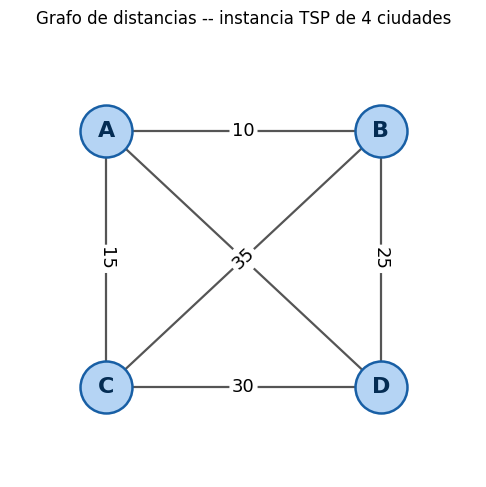

In [8]:
G = nx.Graph()
for (u, v), w in d_matrix.items():
    G.add_edge(u, v, weight=w)

pos = {'A': (0, 1), 'B': (1, 1), 'D': (1, 0), 'C': (0, 0)}

fig, ax = plt.subplots(figsize=(5, 5))
nx.draw_networkx_edges(G, pos, ax=ax, width=1.6, edge_color="#555555")
nx.draw_networkx_nodes(G, pos, ax=ax, node_size=1400, node_color="#B5D4F4",
                        edgecolors="#185FA5", linewidths=1.8)
nx.draw_networkx_labels(G, pos, ax=ax, font_size=16, font_weight="bold", font_color="#042C53")
edge_labels = {(u, v): w for (u, v, w) in G.edges(data="weight")}
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, ax=ax, font_size=13,
                              bbox=dict(boxstyle="round,pad=0.15", fc="white", ec="none"))
ax.set_title("Grafo de distancias -- instancia TSP de 4 ciudades", fontsize=12, pad=12)
ax.set_xlim(-0.35, 1.35); ax.set_ylim(-0.35, 1.35); ax.axis("off")
plt.tight_layout()
plt.show()


---
## g) Conjunto $S^*$ de soluciones óptimas

Buscamos el mínimo valor de $f$ en la tabla anterior y todos los tours que lo alcanzan.

In [9]:
costo_minimo = tabla_costos["f(s)"].min()
S_star = tabla_costos[tabla_costos["f(s)"] == costo_minimo]

print(f"Costo minimo f(s*) = {costo_minimo}")
print(f"|S*| = {len(S_star)}")
print()
print(S_star.to_string(index=False))


Costo minimo f(s*) = 80
|S*| = 2

         tour  f(s)
A->B->D->C->A    80
A->C->D->B->A    80


**¿Por qué hay dos soluciones óptimas empatadas y no una sola?** El libro
define $S^*$ explícitamente como *"a non-empty set of optimal solutions"* — no como un
único elemento. Aquí eso no es un accidente de cálculo: los dos tours óptimos son **el
mismo ciclo recorrido en direcciones opuestas**, y como la matriz de distancias es
simétrica ($d_{ij} = d_{ji}$), recorrer un ciclo en un sentido u otro cuesta exactamente
lo mismo. Verifiquémoslo explícitamente.

In [10]:
tours_optimos = [tuple(t.split("->")[:-1]) for t in S_star["tour"]]
s1, s2 = tours_optimos[0], tours_optimos[1]

es_reverso = s1 == tuple([s2[0]] + list(reversed(s2[1:])))
print(f"s*_1 = {s1}")
print(f"s*_2 = {s2}")
print(f"Es s*_2 el reverso de s*_1? {es_reverso}")


s*_1 = ('A', 'B', 'D', 'C')
s*_2 = ('A', 'C', 'D', 'B')
Es s*_2 el reverso de s*_1? True


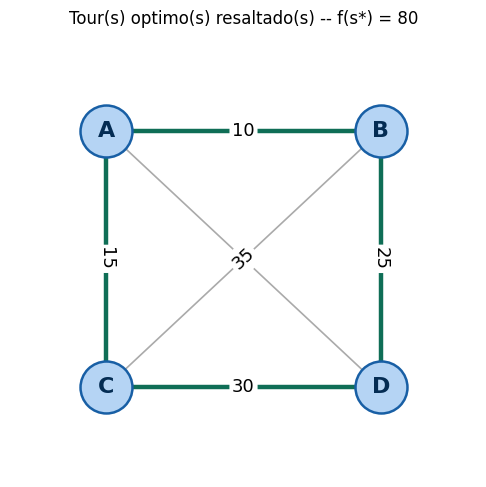

In [11]:
# Grafo resaltando el/los tour(s) optimo(s) -- ahora si podemos revelar la respuesta
fig, ax = plt.subplots(figsize=(5, 5))

edges_optimos = list(zip(s1, s1[1:] + (s1[0],)))
edges_optimos_set = {frozenset(e) for e in edges_optimos}

edge_colors = []
edge_widths = []
for u, v in G.edges():
    if frozenset((u, v)) in edges_optimos_set:
        edge_colors.append("#0F6E56")
        edge_widths.append(3.2)
    else:
        edge_colors.append("#AAAAAA")
        edge_widths.append(1.2)

nx.draw_networkx_edges(G, pos, ax=ax, width=edge_widths, edge_color=edge_colors)
nx.draw_networkx_nodes(G, pos, ax=ax, node_size=1400, node_color="#B5D4F4",
                        edgecolors="#185FA5", linewidths=1.8)
nx.draw_networkx_labels(G, pos, ax=ax, font_size=16, font_weight="bold", font_color="#042C53")
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, ax=ax, font_size=13,
                              bbox=dict(boxstyle="round,pad=0.15", fc="white", ec="none"))
ax.set_title(f"Tour(s) optimo(s) resaltado(s) -- f(s*) = {costo_minimo}", fontsize=12, pad=12)
ax.set_xlim(-0.35, 1.35); ax.set_ylim(-0.35, 1.35); ax.axis("off")
plt.tight_layout()
plt.show()


---
## h) Conjunto de estados $X$ — construcción incremental

Hasta ahora trabajamos siempre con **soluciones completas**. Pero una hormiga (o
cualquier procedimiento constructivo) no aparece con la solución completa de golpe — la
construye **un componente a la vez**. $X$ registra *todas las etapas intermedias* de ese
proceso, no solo el resultado final. Generemos el diagrama de un ejemplo de construcción
paso a paso (no necesariamente el tour óptimo — es solo para ilustrar el mecanismo).

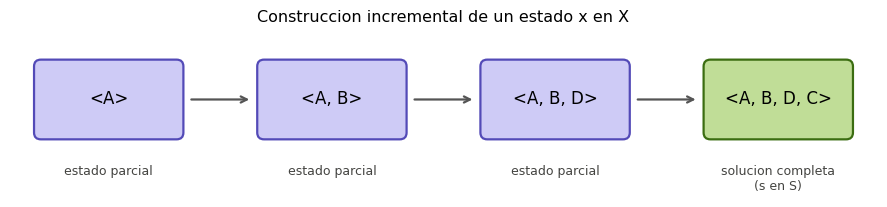

In [12]:
pasos = [('A',), ('A', 'B'), ('A', 'B', 'D'), ('A', 'B', 'D', 'C')]

fig, ax = plt.subplots(figsize=(9, 2.2))
box_w, box_h, gap = 1.7, 0.9, 0.9
xs = [i * (box_w + gap) for i in range(len(pasos))]

for i, (x, paso) in enumerate(zip(xs, pasos)):
    es_completo = (i == len(pasos) - 1)
    fc = "#C0DD97" if es_completo else "#CECBF6"
    ec = "#3B6D11" if es_completo else "#534AB7"
    label = "<" + ", ".join(paso) + ">"
    ax.add_patch(FancyBboxPatch((x, 0), box_w, box_h,
                                 boxstyle="round,pad=0.02,rounding_size=0.08", fc=fc, ec=ec, lw=1.6))
    ax.text(x + box_w / 2, box_h / 2, label, ha="center", va="center", fontsize=12)
    tag = "estado parcial" if not es_completo else "solucion completa\n(s en S)"
    ax.text(x + box_w / 2, -0.32, tag, ha="center", va="top", fontsize=9, color="#444441")
    if i < len(pasos) - 1:
        ax.annotate("", xy=(x + box_w + gap - 0.08, box_h / 2), xytext=(x + box_w + 0.08, box_h / 2),
                     arrowprops=dict(arrowstyle="->", color="#555555", lw=1.6))

ax.set_xlim(-0.3, xs[-1] + box_w + 0.3); ax.set_ylim(-0.7, box_h + 0.3); ax.axis("off")
ax.set_title("Construccion incremental de un estado x en X", fontsize=11.5, pad=10)
plt.tight_layout()
plt.show()


**Sucesores de un estado parcial.** Dado $x = \langle A, B \rangle$, un
sucesor $x'$ se obtiene añadiendo **un** componente que todavía no esté en $x$.

In [13]:
estado_actual = ('A', 'B')
sucesores = [estado_actual + (c,) for c in C if c not in estado_actual]

print(f"Estado actual: {estado_actual}")
print(f"Posibles sucesores x':")
for x_prima in sucesores:
    print(f"  {x_prima}")


Estado actual: ('A', 'B')
Posibles sucesores x':
  ('A', 'B', 'C')
  ('A', 'B', 'D')


---
## Nota conceptual — factibilidad débil ($\tilde{X}$) vs factibilidad fuerte ($\tilde{S}$)

Es tentador pensar que $\tilde{X}$ es simplemente "$\tilde{S}$ pero aplicado a secuencias
parciales" — el mismo criterio, en menor escala. **No es así**:

- $\tilde{S}$ (factibilidad **fuerte**) se aplica solo a secuencias **completas**
  ($s \in S$) y exige el cumplimiento pleno de $\Omega$.
- $\tilde{X}$ (factibilidad **débil**) se aplica a secuencias **parciales**
  ($x \in X$) y exige únicamente que **no sea imposible** completarlas en algo que
  termine cumpliendo $\Omega$.

**Analogía 1 (la del enunciado, del SOP):** si además de visitar cada ciudad una vez
existiera la regla *"$D$ debe visitarse antes que $B$"*, un estado como $\langle A, B
\rangle$ ya sería irrecuperable si $D$ no se ha visitado todavía — nunca podrá completarse
cumpliendo esa regla. Ese estado estaría en $X$, pero jamás en $\tilde{X}$.

**Analogía 2 (cotidiana):** piensa en llenar un crucigrama. Si escribes una letra
incorrecta en una casilla que ya está compartida con otra palabra ya completada, el
crucigrama parcial sigue siendo una secuencia de letras válida como *objeto* (está bien
formado), pero ya es **imposible** de completar correctamente — no importa qué escribas
después, nunca vas a llegar a una solución completa. Eso es exactamente $x \notin
\tilde{X}$: no es que la secuencia esté "mal escrita", es que quedó **sin salida**.

En el TSP que resolvemos aquí, esta situación extrema no se presenta — no hay
restricciones de precedencia. Pero eso no significa que $\tilde{X}$ deje de existir como
concepto: sigue habiendo un predicado propio para $\tilde{X}$, que formulamos y
verificamos a continuación en el numeral (i).

---
## i) Predicado de factibilidad débil para $\tilde{X}$

Para este problema (sin restricciones de precedencia), un estado parcial $x$ **todavía
tiene esperanza** de completarse en una solución válida si y solo si no repite ningún
componente hasta ahora:

$$x \in \tilde{X} \iff \text{ningún componente de } x \text{ aparece más de una vez}$$

Nótese que este predicado es **más débil** que $\Omega$: no exige que $x$ ya cubra todas
las ciudades (eso solo aplica a soluciones completas), solo que lo que lleva construido
hasta ahora no haya cometido un error irreversible.

In [14]:
def en_X_tilde(x):
    """Factibilidad debil: ningun componente de x se repite todavia."""
    return len(x) == len(set(x))

estado_1 = ('A', 'B', 'A')  # repite A
estado_2 = ('A', 'B', 'D')  # sin repetidos, aun incompleto

print(f"{estado_1} en X_tilde? {en_X_tilde(estado_1)}  (repite A -> ya es irrecuperable)")
print(f"{estado_2} en X_tilde? {en_X_tilde(estado_2)}  (sin repetidos -> aun se puede completar)")


('A', 'B', 'A') en X_tilde? False  (repite A -> ya es irrecuperable)
('A', 'B', 'D') en X_tilde? True  (sin repetidos -> aun se puede completar)


---
## j) Grafo de construcción $G_C = (C, L)$

**Coquito — combinación vs. permutación (por qué esto no es $(n-1)!$ otra vez).** En el
numeral (c) contábamos *tours* — secuencias completas donde el **orden** de las ciudades
importa. Aquí contamos **conexiones** (aristas): pares de ciudades sin importar el orden
en que se listan — la conexión $A extbf{-}B$ es la *misma* conexión que $B extbf{-}A$. Contar
pares sin importar el orden es una **combinación**, no una permutación:

$$|L| = \binom{n}{2} = \frac{n!}{2!\,(n-2)!}$$

Para $n=4$: $\binom{4}{2} = \dfrac{4!}{2! \cdot 2!} = \dfrac{24}{4} = 6$.

In [15]:
G_C = nx.complete_graph(C)

print(f"Componentes C = {list(G_C.nodes())}")
print(f"Conexiones L = {list(G_C.edges())}")
print(f"|L| = {G_C.number_of_edges()}  (esperado: C(4,2) = {math.comb(4, 2)})")


Componentes C = ['A', 'B', 'C', 'D']
Conexiones L = [('A', 'B'), ('A', 'C'), ('A', 'D'), ('B', 'C'), ('B', 'D'), ('C', 'D')]
|L| = 6  (esperado: C(4,2) = 6)


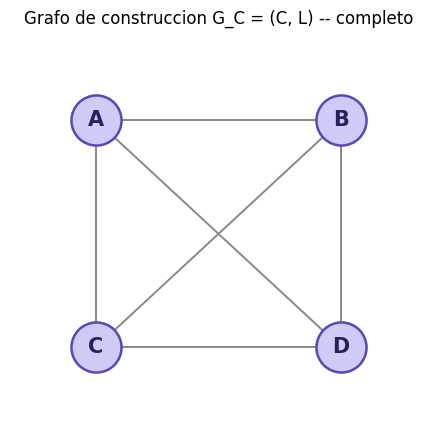

In [16]:
fig, ax = plt.subplots(figsize=(4.5, 4.5))
nx.draw_networkx_edges(G_C, pos, ax=ax, width=1.4, edge_color="#888888")
nx.draw_networkx_nodes(G_C, pos, ax=ax, node_size=1300, node_color="#CECBF6",
                        edgecolors="#534AB7", linewidths=1.8)
nx.draw_networkx_labels(G_C, pos, ax=ax, font_size=15, font_weight="bold", font_color="#26215C")
ax.set_title("Grafo de construccion G_C = (C, L) -- completo", fontsize=12, pad=12)
ax.set_xlim(-0.35, 1.35); ax.set_ylim(-0.35, 1.35); ax.axis("off")
plt.tight_layout()
plt.show()


---
## Cierre — resumen de símbolos aplicados a esta instancia

| Símbolo | Definición general | Valor en esta instancia |
|---|---|---|
| $C$ | Componentes | $\{A,B,C,D\}$ |
| $n$ | Tamaño de $C$ | $4$ |
| $S$ | Soluciones candidatas | $24$ permutaciones ($4!$) |
| Clases circulares | Soluciones distintas como tour | $6$ ($(4-1)!$) |
| $\Omega$ | Restricciones | Cubrir $C$, sin repetidos |
| $\tilde{S}$ | Soluciones factibles | $\tilde{S} = S$, $|\tilde{S}| = 24$ |
| $f(s)$ | Costo del tour, ec. (3.1) cap. 3 | Entre 80 y 95 según el tour |
| $S^*$ | Soluciones óptimas | 2 tours empatados, $f(s^*)=80$ |
| $X$ | Estados (secuencias parciales) | Ilustrado con construcción incremental |
| $\tilde{X}$ | Estados factibles (débil) | Sin repetidos hasta el momento |
| $G_C=(C,L)$ | Grafo de construcción | Completo, $|L|=6$ |

## Referencias

- Dorigo, M. & Stützle, T. (2004). *Ant Colony Optimization*. MIT Press. §2.1, §2.2.1,
  §2.3.1 (representación del problema en TSP); capítulo 3, ecuación (3.1) (función
  objetivo).
- Enunciado de este ejercicio: [`../TSP-exercise.md`](../TSP-exercise.md).